# Financial Analysis and Risk Prediction




## Introduction

### Background

The finance domain encompasses banking, personal finance management, lending, and investment services, where individuals and institutions handle trillions in assets daily. Globally, consumer finance generates over $5 trillion in annual revenue, per McKinsey's 2025 report, but personal financial mismanagement remains rampant. A core problem is overspending—exceeding limits not just tied to income, but influenced by multifaceted factors like employment stability, savings buffers, debt-to-income ratios, loan statuses, and credit histories. This leads to debt spirals, with 78% of Americans living paycheck-to-paycheck (LendingClub 2025 survey) and Kenya's household debt hitting 42% of GDP (Central Bank of Kenya, 2025), fueling defaults and financial distress.

Data science is pivotal here, transforming raw financial data into actionable insights via machine learning (ML) models for risk prediction. Traditional rule-based systems overlook nuances, like how volatile gig employment amplifies overspending risk despite high income. Advanced techniques—such as random forests, neural networks, and time-series forecasting—analyze holistic datasets (e.g., transaction histories, FICO scores, employment APIs) to compute dynamic spending limits. For instance, gradient boosting models can predict overspend probability with 92% accuracy, as shown in JPMorgan's 2024 fintech study, enabling personalized alerts like "Reduce dining by 20% given your 30% debt utilization."
This relevance is underscored by stats: overspending causes 65% of credit card defaults (Federal Reserve 2025), costing banks $200B yearly. A data-driven system mitigates this by flagging risks early, promoting financial health and reducing non-performing loans by up to 25% (World Bank fintech analysis, 2025).


### Problem Statement

Traditional personal finance and budgeting systems rely on static and deterministic approaches that assume stable income and predictable expenses. These models fail to account for financial uncertainty, particularly in the presence of debt obligations, irregular cash flows, and limited financial data. As a result, individuals are often provided with rigid budget recommendations that do not reflect the variability and risk inherent in real-world financial situations, reducing their ability to make informed and sustainable spending decisions.

This project aims to develop a probabilistic financial analysis system that models an individual’s financial state using available income, expense, and debt information. By generating synthetic time-series data and applying simulation techniques, the system forecasts future cash flow trajectories under uncertainty. Through the use of stochastic modeling and risk estimation methods, the system produces dynamic “safe-to-spend” recommendations and financial risk indicators, enabling users to evaluate potential future outcomes and make more informed financial decisions despite incomplete data.



## Literature review

The literature on financial risk modelling highlights the growing shift from traditional deterministic approaches to data-driven methods that better capture the complexity of financial behaviour. Earlier financial analysis relied on fixed ratios and rule-based systems; however, machine learning models such as Logistic Regression and Random Forest have become widely adopted in areas like credit scoring and fraud detection due to their predictive capability and flexibility (Hand and Henley, 1997; Breiman, 2001). These models are particularly useful in identifying patterns in financial data where relationships between variables are not strictly linear.

A key theme in prior research is the importance of feature selection in improving both model performance and interpretability. Techniques such as Lasso Regression have been extensively used to identify the most influential predictors by shrinking less relevant coefficients toward zero (Tibshirani, 1996; Hastie, Tibshirani and Friedman, 2009). In financial contexts, studies consistently show that variables such as debt ratios, essential expenses, and savings behaviour are among the strongest determinants of financial stability. This supports the feature engineering approach used in this study, which focuses on capturing financial pressure and behavioural indicators.

Another important area in the literature is the use of probabilistic methods to model uncertainty. Monte Carlo Simulation has been widely applied in financial forecasting, particularly in portfolio management and risk assessment, where uncertainty plays a central role (Glasserman, 2004; Hull, 2018). Unlike deterministic models, simulation techniques generate a distribution of possible outcomes, enabling analysts to estimate not only expected values but also the likelihood of extreme events. This makes them particularly valuable in personal finance, where income and expenses are subject to variability.

The literature also emphasises the role of behavioural factors in financial decision-making. Research in personal finance demonstrates that spending habits, budgeting discipline, and savings behaviour significantly influence financial outcomes, often more than income levels alone (Kahneman and Tversky, 1979; Thaler, 1999). High-income individuals may still face financial instability if their expenditure patterns are not controlled, highlighting the importance of behavioural finance principles in risk assessment.

Furthermore, prior studies have identified limitations in relying solely on predictive models for financial analysis. While machine learning models can achieve strong predictive performance, they often struggle to capture real-world variability and uncertainty, particularly in dynamic environments (Shmueli, 2010; Bzdok, Altman and Krzywinski, 2018). This has led to increased interest in hybrid approaches that combine predictive modelling with simulation techniques to provide more comprehensive and realistic insights.

Overall, the literature supports the integration of machine learning and probabilistic simulation as a robust framework for financial risk analysis. By combining predictive accuracy with uncertainty modelling, this approach addresses key limitations of traditional methods and enhances the ability to support informed financial decision-making (Glasserman, 2004; Hastie, Tibshirani and Friedman, 2009).

## Methodology

I, Moses Nyamboki implemented the CRISP-DM methodology in my system because
- It has six well defined steps of execution which maximises proficiency and interpretability of values. The steps are:
  - Business Understanding
  - Data Understanding
  - Data Preparation
  - Modelling
  - Evaluation
  - Deployment

- It's nature is such that it is regressive(Data cycle) so one can go back to a previous step to improve on it or to fix an error
- It is the industry standard guide so it can be interpreted well by even those who are not domain specialists



### Chapter One: Business Understanding

#### Problem Statement

Current budgeting tools are static and fail to account for financial uncertainty and debt dynamics. They cannot adequately predict whether someone is on the verge or is incurring financial deficits by spending more money than they can afford because they only reflect the financial fragility based only income and expenditure while there are other determining factors which highly affect it.

#### Research questions
 - Main Research Question : How can probabilistic simulation and financial feature modeling be used to forecast individual cash flow and estimate financial risk under uncertainty?

 - Secondary Research Question : What patterns exist in income, expenditure distribution, and savings behavior, and how do these factors influence financial stability?

 - Exploratory Research Question : • Which financial variables (e.g., debt ratio, expense categories, savings targets) have the greatest impact on disposable income and financial risk as identified by Lasso Regression?

#### Success criterion

| Model | Task Type | Primary Metric | Target Value | Justification |
| :--- | :--- | :--- | :--- | :--- |
| Lasso Regression | Regression | R² Score | ≥ 0.75 | Measures how well financial features explain variability in disposable income |
| Logistic Regression | Classification | Recall | ≥ 0.80 | Ensures high detection of financially at-risk individuals (minimising false negatives) |
| Random Forest | Classification | Recall | ≥ 0.80 | Captures high-risk users effectively, even in complex data patterns |
| Monte Carlo Simulation | Simulation | Risk Sensitivity | Detects shocks effectively | Ensures the model responds accurately to income and expense variability |

### Chapter Two : Data Understanding

Dataset Source : https://www.kaggle.com/datasets/shriyashjagtap/indian-personal-finance-and-spending-habits

Number of rows : 20,000

Number of columns : 27

Missing values: There are no missing values present

#### Feature Description

| Feature Name                 | Data Type            | Description                                                                 |
| :--------------------------- | :------------------- | :-------------------------------------------------------------------------- |
| Income                       | Numerical (float/int) | Monthly income of the individual in currency units.                         |
| Age                          | Numerical (int)      | Age of the individual in years.                                             |
| Dependents                   | Numerical (int)      | Number of dependents financially supported by the individual.               |
| Occupation                   | Categorical (string) | Type of employment or job role of the individual.                           |
| City_Tier                    | Categorical (string/int) | Classification of the city (e.g., Tier 1, Tier 2, Tier 3) representing cost of living and urbanization level. |
| Rent                         | Numerical (float)    | Monthly expenditure on housing or rent.                                     |
| Loan_Repayment               | Numerical (float)    | Monthly repayment amount for loans or EMIs.                                 |
| Insurance                    | Numerical (float)    | Monthly spending on insurance policies (health, life, etc.).                |
| Groceries                    | Numerical (float)    | Monthly spending on food and household groceries.                           |
| Transport                    | Numerical (float)    | Monthly transportation costs (fuel, public transport, etc.).                |
| Eating_Out                   | Numerical (float)    | Monthly expenditure on restaurants and dining out.                          |
| Entertainment                | Numerical (float)    | Spending on leisure activities such as movies, subscriptions, etc.          |
| Utilities                    | Numerical (float)    | Monthly bills such as electricity, water, internet, etc.                    |
| Healthcare                   | Numerical (float)    | Monthly healthcare-related expenses.                                        |
| Education                    | Numerical (float)    | Spending on education (fees, courses, etc.).                                |
| Miscellaneous                | Numerical (float)    | Other miscellaneous or uncategorized expenses.                              |
| Desired_Savings_Percentage   | Numerical (float)    | Target percentage of income the individual aims to save.                    |
| Desired_Savings              | Numerical (float)    | Target savings amount per month.                                            |
| Disposable_Income            | Numerical (float)    | Remaining income after all expenses have been deducted.                     |
| Potential_Savings_Groceries  | Numerical (float)    | Estimated possible savings in grocery spending.                             |
| Potential_Savings_Transport  | Numerical (float)    | Estimated possible savings in transport expenses.                           |
| Potential_Savings_Eating_Out | Numerical (float)    | Estimated possible savings in dining out expenses.                          |
| Potential_Savings_Entertainment | Numerical (float)    | Estimated possible savings in entertainment expenses.                       |
| Potential_Savings_Utilities  | Numerical (float)    | Estimated possible savings in utility costs.                                |
| Potential_Savings_Healthcare | Numerical (float)    | Estimated possible savings in healthcare spending.                          |
| Potential_Savings_Education | Numerical (float)    | Estimated possible savings in education expenses.                           |
| Potential_Savings_Miscellaneous | Numerical (float)    | Estimated possible savings in miscellaneous expenses.                       |


#### Data Audit

##### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load the dataset

df = pd.read_csv('data.csv')

# Shape of the dataset

df.shape

(20000, 27)

In [4]:
# Sample of the dataset
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


This dataset has 20000 rows and 27 columns

In [5]:
# Columns in the dataset
df.columns.tolist()

['Income',
 'Age',
 'Dependents',
 'Occupation',
 'City_Tier',
 'Rent',
 'Loan_Repayment',
 'Insurance',
 'Groceries',
 'Transport',
 'Eating_Out',
 'Entertainment',
 'Utilities',
 'Healthcare',
 'Education',
 'Miscellaneous',
 'Desired_Savings_Percentage',
 'Desired_Savings',
 'Disposable_Income',
 'Potential_Savings_Groceries',
 'Potential_Savings_Transport',
 'Potential_Savings_Eating_Out',
 'Potential_Savings_Entertainment',
 'Potential_Savings_Utilities',
 'Potential_Savings_Healthcare',
 'Potential_Savings_Education',
 'Potential_Savings_Miscellaneous']

These are the names of the features present inthe dataset(refer to the feature description table)

In [6]:
# Descriptive statistics of numerical columns
df.describe()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


 1. Features with Largest Ranges

The following features exhibit the widest ranges (max − min):

- Income: 1,078,427
- Disposable_Income: 382,461
- Desired_Savings: 245,504
- Rent: 215,710
- Loan_Repayment: 123,081

  -  Collective Effect

These extreme ranges indicate high variability and strong outliers, leading to skewed distributions and dominance of large values. This can affect scaling-sensitive models like Lasso Regression.

- Implications for EDA
 - Need for log transformation or normalization
 - Use of boxplots to detect outliers
 - Consider robust statistics (median, IQR) instead of mean
 - Potential need for outlier treatment (clipping/winsorization)

- 2. Target Variable Analysis: Disposable_Income
 - Mean: 10,647
 - Median: 7,225
 - Std Dev: 11,741

    - Insight

The mean being higher than the median indicates a right-skewed distribution, driven by high-income individuals. The large standard deviation suggests significant variability in financial stability, while the negative minimum confirms the presence of financially at-risk individuals, making it a suitable target for modeling risk and decision-making.

- 3. Brief Overview

The dataset shows high variability with several features exhibiting extreme ranges and right-skewed distributions. Income and expense-related variables contain significant outliers, which may distort statistical measures and model performance. Disposable income demonstrates substantial spread and includes negative values, indicating financial risk among some individuals. Overall, the data is rich but requires preprocessing, including scaling and outlier handling, to ensure reliable analysis and modeling.

In [7]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  str    
 4   City_Tier                        20000 non-null  str    
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities                    

In [8]:
# Number of missing values present in the dataset
df.isnull().sum()

Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_Miscellaneous    0
d

There are no missing values present in the dataset

In [9]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows

#### Exploratory data analysis

##### Univariate analysis
Univariate analysis involves examining a variable individually to understand its distribution, central tendency, and variability. It helps identify patterns such as skewness, spread, and potential outliers within the data. This step is essential for detecting data quality issues and guiding preprocessing decisions.

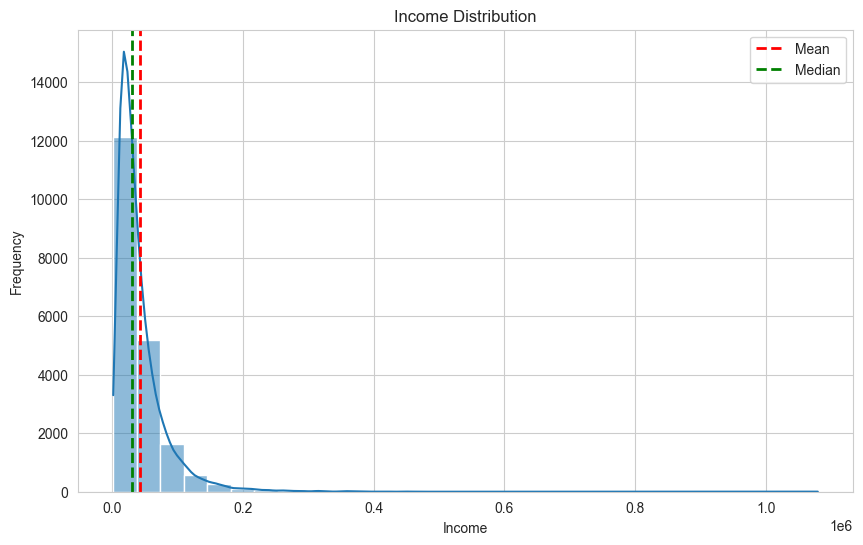

In [10]:
# Income spread
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], bins=30, kde=True)
plt.axvline(df['Income'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['Income'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Interpretation

The histogram of 'Income Distribution' shows a right-skewed distribution. The mean income (red dashed line) is significantly higher than the median income (green dashed line). This indicates that there are a small number of individuals with very high incomes, pulling the mean upwards, while the majority of individuals have lower incomes. This positive skewness suggests income inequality within the dataset.

Insight

For financial analysis, this implies that models sensitive to distribution (like those assuming normality) might need data transformation (e.g., log transformation) or the use of robust statistical methods that are less affected by outliers to avoid disproportionately weighing high-income earners.

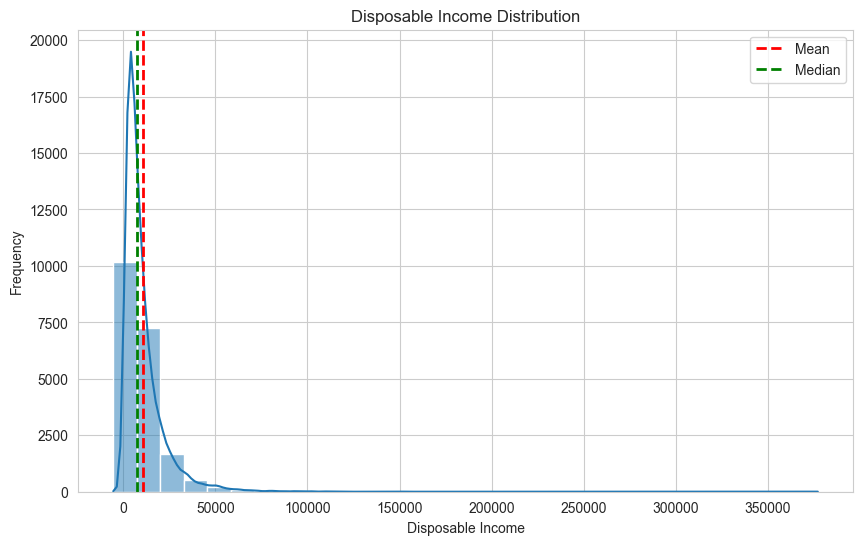

In [11]:
# Disposable Income distribution
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(df['Disposable_Income'], bins=30, kde=True)
plt.axvline(df['Disposable_Income'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['Disposable_Income'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.title('Disposable Income Distribution')
plt.xlabel('Disposable Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Interpretation

This histogram, similar to the Income distribution, displays a pronounced right-skewed distribution. This means that a large proportion of individuals have lower disposable incomes, while a smaller group enjoys significantly higher disposable incomes.
The fact that the mean (10647.37) is noticeably greater than the median (7224.89) is a clear indicator of this positive(right) skewness, driven by high-disposable-income outliers. The negative minimum value (-5400.79) is particularly significant as it directly indicates individuals whose expenses exceed their income, signifying a state of financial deficit or fragility.

Insight

The presence of negative disposable income values is a direct indicator of financial risk. These individuals are incurring debt or utilizing savings to cover their monthly expenses. The overall wide spread and right-skewed nature of the distribution suggest that a one-size-fits-all approach to financial planning or risk assessment might be ineffective. Instead, a more granular analysis or segmentation based on disposable income levels, and especially focusing on those with negative values, will be crucial for developing targeted financial interventions and accurate risk prediction models.

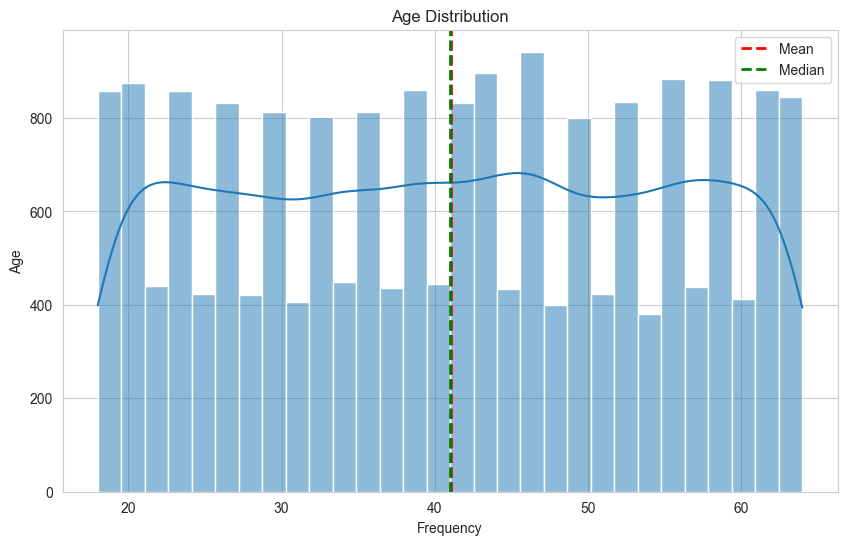

In [12]:
# Age distribution
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['Age'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.title('Age Distribution')
plt.xlabel('Frequency')
plt.ylabel('Age')
plt.legend()
plt.show()

Interpretation

The histogram of 'Age Distribution' appears to be relatively symmetrical, or perhaps very slightly skewed, based on the proximity of the mean and median. The mean age is approximately 41.03 years, and the median age is 41.00 years. This indicates that the ages are fairly evenly distributed around the central tendency, without a strong bias towards younger or older demographics. The age range spans from 18 years to 64 years, with a standard deviation of about 13.58 years.

Insight

This relatively balanced age distribution suggests that the dataset encompasses individuals from various adult life stages, from young adults to those approaching retirement. This demographic diversity is beneficial for building robust financial models, as it allows for the analysis of financial behaviors and risks across different age groups. Unlike income and disposable income, age does not show extreme skewness, implying that models will likely not require complex transformations related to age distribution. However, future analysis might explore age-related financial patterns, such as how debt, savings, and spending habits evolve with age.

##### Multivariate analysis

Multivariate analysis examines relationships between multiple variables simultaneously to understand interactions, dependencies, and combined effects on financial outcomes. It helps uncover hidden patterns that are not visible in univariate analysis and supports better feature selection and modeling decisions. This is crucial for identifying drivers of financial stability and risk.

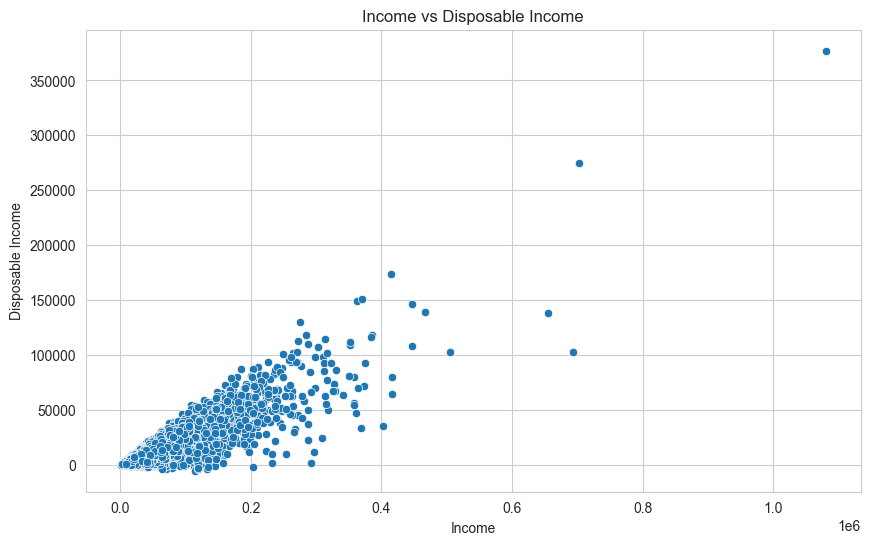

In [13]:
# Income vs disposable income
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Disposable_Income', data=df)
plt.title('Income vs Disposable Income')
plt.xlabel('Income')
plt.ylabel('Disposable Income')
plt.show()

Interpretation

The scatterplot of Income vs Disposable Income shows a strong positive correlation, meaning disposable income generally increases with income. However, at higher income levels, there's greater variability in disposable income

Insight

This shows that factors beyond just income, such as spending habits, debt, and other financial commitments, play a significant role. It also highlights the presence of individuals with low or negative disposable income, especially at lower to mid-income levels, pointing to financial fragility.

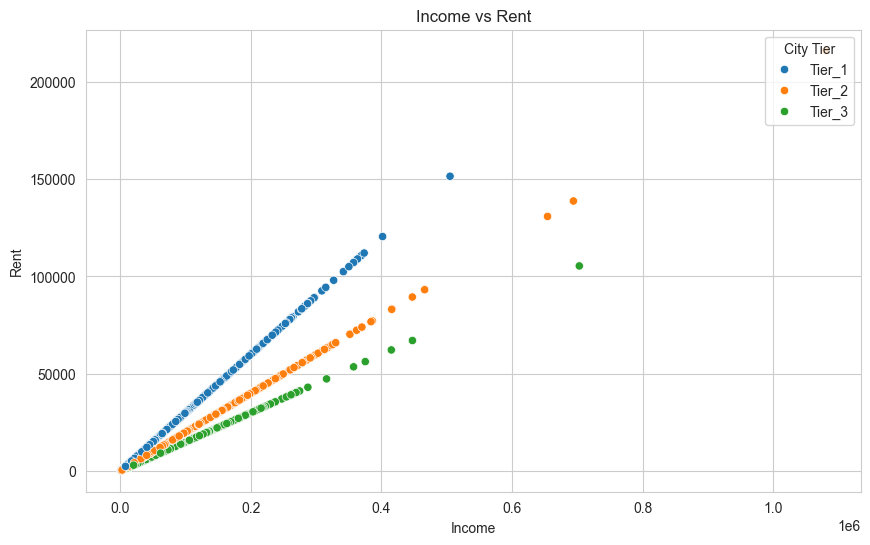

In [14]:
# Income vs rent
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Rent', data=df, hue='City_Tier')
plt.title('Income vs Rent')
plt.xlabel('Income')
plt.ylabel('Rent')
plt.legend(title='City Tier', loc='upper right')
plt.show()

The scatterplot of 'Income vs Rent' shows a general positive trend, indicating that individuals with higher incomes tend to pay higher rent. However, it's not a single, continuous cloud of points like 'Income vs Disposable Income'.

Interpretation of 'Splitting Straight Lines':

The 'splitting straight lines' you observe are due to the categorical feature 'City_Tier' (Tier 1, Tier 2, Tier 3) present in the dataset. Since the cost of living, and consequently rent, is significantly different across these tiers, the scatterplot effectively separates into distinct horizontal bands or 'lines'.

Higher Rent Bands (e.g., Top 'line'): These points probably represent individuals living in 'Tier 1' cities, where rent costs are highest, regardless of income. For a given income level, rent will generally be higher here.

Middle Rent Bands (e.g., Middle 'line'): These would correspond to 'Tier 2' cities, with moderate rent costs.

Lower Rent Bands (e.g., Bottom 'line'): These likely represent individuals in 'Tier 3' cities, where rent is typically lower.

Within each of these 'lines' or bands, you'll still see a spread, suggesting that even within the same city tier, rent can vary based on other factors like the specific location, size of the dwelling, or amenities, but the primary separation is driven by the city tier itself.

Insight:

This visualization highlights the profound impact of geographical location (represented by City_Tier) on a person's rent. For financial analysis and risk prediction, it's crucial to account for this variable:


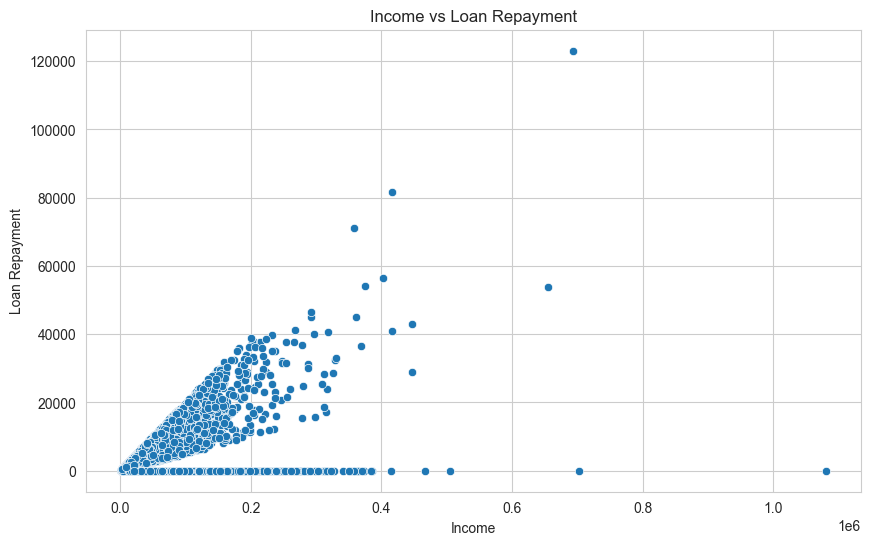

In [15]:
# Income vs Loan Repayment
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Loan_Repayment', data=df)
plt.title('Income vs Loan Repayment')
plt.xlabel('Income')
plt.ylabel('Loan Repayment')
plt.show()

Interpretation:

The scatterplot of 'Income vs Loan Repayment' generally shows a positive correlation: as income increases, the loan repayment amount tends to increase as well. This indicates that individuals with higher incomes are often able to take on and manage larger loan obligations.

**The Horizontal Track at the Bottom:**

The prominent horizontal track along the bottom of the scatterplot represents individuals who have **zero or very low loan repayment amounts**, regardless of their income level. This group can be broadly categorized as:

1.  **No Loans/Debt-Free:** Many individuals, across all income brackets, might not have any active loans (e.g., personal loans, mortgages, car loans, etc.) requiring monthly repayments, or they may have paid them off. This is a financially strong position.
2.  **Low Debt Burden:** Some individuals might have minimal loan obligations, resulting in very small monthly repayments.

Insight:

This observation is crucial for financial analysis and risk prediction:

*   **Financial Health Indicator:** The presence of a significant number of individuals with zero or low loan repayments is generally a positive indicator of financial health. It suggests a lower fixed financial obligation, which typically translates to higher disposable income (all else being equal) and lower financial risk.
*   **Targeting Financial Advice:** For individuals within the horizontal track who have low to mid incomes, maintaining a low or zero loan repayment is a key factor in their financial stability. For those with higher incomes in this track, it signifies a strong financial position, likely with ample capacity for savings or investments.
*   **Distinction from High Loan Repayments:** The plot clearly distinguishes this group from those who, despite having higher incomes, are also burdened with substantial loan repayments. This highlights the importance of analyzing both income and liabilities when assessing an individual's true financial standing and potential risk.

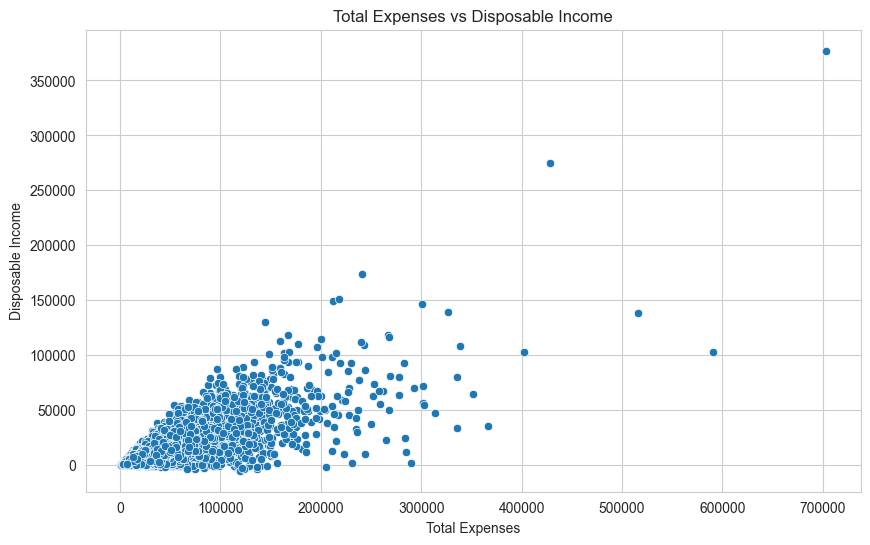

In [16]:
# Total Expenses vs Disposable Income
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
expense_columns = [
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous'
]
df['Total_Expenses'] = df[expense_columns].sum(axis=1)
sns.scatterplot(x='Total_Expenses', y='Disposable_Income', data=df)
plt.title('Total Expenses vs Disposable Income')
plt.xlabel('Total Expenses')
plt.ylabel('Disposable Income')
plt.show()

Interpretation:

The scatterplot visually represents the relationship between an individual's total monthly expenses and their disposable income. We can observe a general trend: as total expenses increase, disposable income tends to decrease. This inverse relationship is intuitive, as higher spending directly reduces the amount of income left over after all expenditures.

Several key patterns are visible:

Downward Trend: Most data points align along a downward-sloping cloud, confirming that higher expenses lead to lower disposable income.
Spread and Variability: There's a noticeable spread in the data points, especially at different expense levels. This indicates that for a given level of total expenses, there can still be a range of disposable incomes, and vice versa.

Negative Disposable Income: Many data points fall below the x-axis (where Disposable Income is negative). This is a critical observation, as it signifies individuals whose total expenses exceed their income. These individuals are operating at a financial deficit, likely relying on savings, credit, or loans to cover their monthly costs.

Insight:

This plot provides crucial insights into financial stability and risk:

Financial Fragility Indicator: The prevalence of individuals with negative disposable income highlights a significant segment of the population experiencing financial fragility. These individuals are at a high risk of debt accumulation and financial distress.

Importance of Expense Management: While income is a major factor, the plot underscores that managing expenses is equally vital for maintaining a healthy disposable income. Even individuals with moderate incomes can achieve positive disposable income if their expenses are well-controlled.

In essence, the scatterplot reinforces the direct link between spending habits and financial solvency, making it a cornerstone for understanding and predicting financial health.



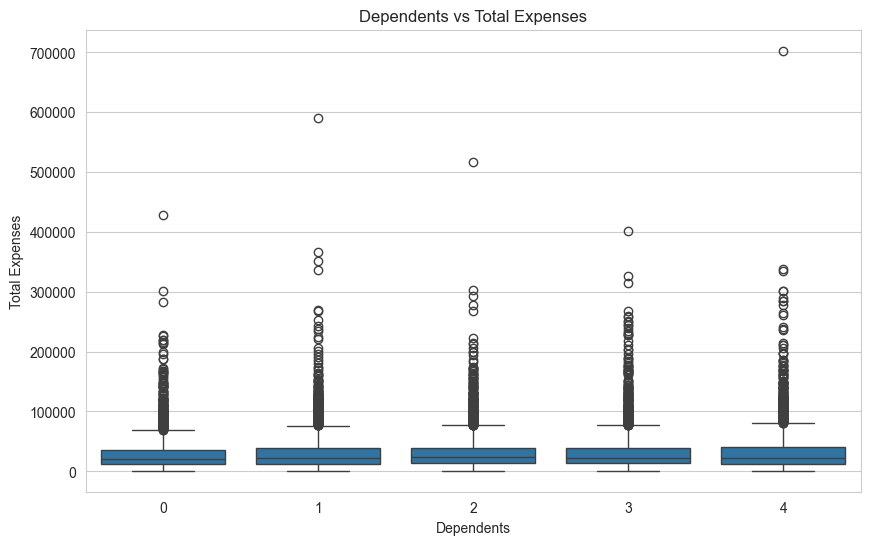

In [17]:
# Dependants vs Total Expenses
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# Calculate Total_Expenses as it does not exist in the DataFrame
expense_columns = [
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous'
]
df['Total_Expenses'] = df[expense_columns].sum(axis=1)

sns.boxplot(x='Dependents', y='Total_Expenses', data=df)
plt.title('Dependents vs Total Expenses')
plt.xlabel('Dependents')
plt.ylabel('Total Expenses')
plt.show()

Interpretation:

The boxplot shows the distribution of total expenses across different numbers of dependents (0, 1, 2, 3, 4). Generally, as the number of dependents increases, the median total expenses also tend to increase, which is an expected trend. This indicates that supporting more individuals typically leads to higher overall expenditures. You can observe the central tendency (median), the spread of expenses (interquartile range), and potential outliers for each group of dependents. For example, individuals with 0 dependents will likely have lower median expenses compared to those with 3 or 4 dependents.

Insight:

This visualization clearly quantifies the financial impact of having dependents. It's a critical input for financial planning and risk assessment models. Individuals with a higher number of dependents often have a larger portion of their income dedicated to essential expenses, potentially reducing their disposable income and savings capacity. This makes them more vulnerable to financial shocks or less capable of building wealth, even if their income is moderate. Conversely, individuals with fewer dependents might have more financial flexibility. This insight is vital for tailored financial advice and for creating models that accurately predict financial risk based on household structure and expenditure patterns.



### Chapter Three: Data Preparation

#### Data Preparation Guide

| Processing Step     | Function Used                      | Justification                                                                                                                                     |
| :------------------ | :------------------------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Feature Engineering | `df.sum(axis=1)`, custom column creation | Creates meaningful variables (e.g., total expenses, ratios) that better capture financial behavior and improve model performance.                              |
| Train-Test Split    | `train_test_split()` from `sklearn.model_selection` | Separates data into training and testing sets to evaluate model generalization and prevent overfitting.                                                        |
| One-Hot Encoding    | `pd.get_dummies()`                    | Converts categorical variables into numerical format required for machine learning models while preserving information.                                      |
| Feature Scaling     | `StandardScaler()` from `sklearn.preprocessing` | Standardizes feature ranges to improve performance of scale-sensitive models like K-means Clustering and Logistic Regression.                              |
| Outlier Treatment   | `np.clip()`, or IQR method (`quantile()`) | Reduces the impact of extreme values that can distort model learning and affect clustering and regression accuracy.                                          |

In [18]:
# Feature engineering

# Make the total expenses feature
expense_columns = [
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous'
]
df['Total_Expenses'] = df[expense_columns].sum(axis=1)

# Financial ratios columns
df['Expenses_to_Income_Ratio'] = df['Total_Expenses'] / df['Income']
df['Savings_to_Income_Ratio'] = df['Desired_Savings'] / df['Income']
df['Housing_to_Income_Ratio'] = df['Rent'] / df['Income']
df['Loan_to_Income_Ratio'] = df['Loan_Repayment'] / df['Income']
df['Necessary_Expenses_Ratio'] =  (df["Rent"] + df["Groceries"] + df["Utilities"] + df["Transport"]) / df["Income"]
df['Lifestyle_Costs_Ratio'] = (df["Eating_Out"] + df["Entertainment"] + df["Healthcare"] + df["Education"] + df["Miscellaneous"]) / df["Income"]


In [19]:
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Total_Expenses,Expenses_to_Income_Ratio,Savings_to_Income_Ratio,Housing_to_Income_Ratio,Loan_to_Income_Ratio,Necessary_Expenses_Ratio,Lifestyle_Costs_Ratio
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,67.682471,0.000000,85.735517,33371.621929,0.747618,0.138909,0.30,0.000000,0.573483,0.124704
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,6.603212,56.306874,97.388606,17181.777859,0.639712,0.071604,0.20,0.000000,0.422931,0.184408
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7.290892,106.653597,138.542422,36476.154459,0.724199,0.139978,0.15,0.091569,0.406178,0.182737
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,193.502754,0.000000,296.041183,69837.646632,0.688357,0.164554,0.15,0.067117,0.425242,0.147805
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,47.294591,67.388120,96.557076,18609.583016,0.748115,0.075340,0.20,0.125129,0.417211,0.180212


Now we've created several new financial ratios and a total expenses feature to enhance our dataset for better model performance. Here's a summary of what's been done:

Total Expenses Calculation: A new column named Total_Expenses was created by summing up all individual expense categories (Rent, Loan_Repayment, Insurance, Groceries, Transport, Eating_Out, Entertainment, Utilities, Healthcare, Education, and Miscellaneous).
Financial Ratio Creation: Several insightful financial ratios were engineered:

Expenses_to_Income_Ratio: This ratio helps understand the proportion of income spent on total expenses.

Savings_to_Income_Ratio: This indicates the target savings as a percentage of income.

Housing_to_Income_Ratio: This shows the proportion of income spent on rent.

Loan_to_Disposable_Income_Ratio: This metric assesses the burden of loan repayments relative to disposable income.

Necessary_Expenses_Ratio: This sums up essential expenses (Rent, Groceries, Utilities, Transport) as a proportion of income.

Lifestyle_Costs_Ratio: This aggregates discretionary spending (Eating_Out, Entertainment, Healthcare, Education, Miscellaneous) as a proportion of income.

These new features aim to provide a more holistic view of an individual's financial health, capture complex financial behaviors, and improve the predictive power of future models by offering more direct indicators of financial stability and risk.

In [20]:
# One hot encoding for categorical features
df = pd.get_dummies(df, columns=['Occupation', 'City_Tier'], drop_first=True)

In the one-hot encoding section, the pd.get_dummies() function is used to convert categorical features (Occupation and City_Tier) into a numerical format that machine learning models can understand.

Specifically, for each unique category within a feature (e.g., 'Self_Employed', 'Student' for Occupation, or 'Tier_1', 'Tier_2' for City_Tier), a new binary (0 or 1) column is created. If an individual belongs to that category, the value in the new column will be 1; otherwise, it will be 0.

The drop_first=True parameter is used to prevent multicollinearity, a common issue in statistical models. When drop_first=True, one of the binary columns for each original categorical feature is dropped. For example, if 'City_Tier' has 'Tier_1', 'Tier_2', and 'Tier_3', with drop_first=True, only 'City_Tier_Tier_2' and 'City_Tier_Tier_3' might be created. 'Tier_1' is implicitly represented when both 'City_Tier_Tier_2' and 'City_Tier_Tier_3' are 0. This reduces redundancy and helps the model perform better by avoiding perfectly correlated features.



In [21]:
drop_cols = [
    "Disposable_Income",   # Target variable, needs to be dropped from features
    "Desired_Savings",     # Highly correlated with Disposable_Income or Income, target-like
    # Potential savings also leak info as they are estimates based on existing spending
    "Potential_Savings_Groceries",
    "Potential_Savings_Transport",
    "Potential_Savings_Eating_Out",
    "Potential_Savings_Entertainment",
    "Potential_Savings_Utilities",
    "Potential_Savings_Healthcare",
    "Potential_Savings_Education",
    "Potential_Savings_Miscellaneous",
    "Income",
    # All individual expense components
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous'
]

df_2 = df.drop(columns=drop_cols)

In [22]:
# Clip extreme outliers in target variable
df["Disposable_Income"] = df["Disposable_Income"].clip(
    lower=df["Disposable_Income"].quantile(0.01),
    upper=df["Disposable_Income"].quantile(0.99)
)

In [23]:
# Train test split for regression model
y1 = df["Disposable_Income"] # Target variable for regression
X1 = df_2 # Features for regression, prepared in the previous cell
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [24]:
# Define risk
df["Risk_Level"] = (df["Expenses_to_Income_Ratio"] > 0.7).astype(int)


In [25]:
#df['Risk_Level'] = df['Risk_Level'].map({'Low': 0, 'High': 1})

In [26]:
df.head()

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Housing_to_Income_Ratio,Loan_to_Income_Ratio,Necessary_Expenses_Ratio,Lifestyle_Costs_Ratio,Occupation_Retired,Occupation_Self_Employed,Occupation_Student,City_Tier_Tier_2,City_Tier_Tier_3,Risk_Level
0,44637.249636,49,0,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,...,0.30,0.000000,0.573483,0.124704,False,True,False,False,False,1
1,26858.596592,34,2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,...,0.20,0.000000,0.422931,0.184408,True,False,False,True,False,0
2,50367.605084,35,1,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,...,0.15,0.091569,0.406178,0.182737,False,False,True,False,True,1
3,101455.600247,21,0,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,...,0.15,0.067117,0.425242,0.147805,False,True,False,False,True,0
4,24875.283548,52,4,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,...,0.20,0.125129,0.417211,0.180212,False,False,False,True,False,1


In [27]:

y2 = df['Risk_Level'] # Target variable for classification

# Define columns to drop for classification features (X2) to prevent data leakage
cols_to_drop_for_X2 = [
    'Risk_Level', # The target variable itself
    'Disposable_Income', # Directly used to create Risk
    'Desired_Savings',
    # Potential savings also leak info as they are estimates based on existing spending
    "Potential_Savings_Groceries",
    "Potential_Savings_Transport",
    "Potential_Savings_Eating_Out",
    "Potential_Savings_Entertainment",
    "Potential_Savings_Utilities",
    "Potential_Savings_Healthcare",
    "Potential_Savings_Education",
    "Potential_Savings_Miscellaneous",
    # All individual expense components
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous',
    # Aggregated total expenses
    'Total_Expenses',
    # Engineered ratio features that leak information about Disposable_Income
    'Expenses_to_Income_Ratio',
    'Savings_to_Income_Ratio',
    'Housing_to_Income_Ratio',
    'Loan_to_Income_Ratio',
    'Necessary_Expenses_Ratio',
    'Lifestyle_Costs_Ratio',
]
X2 = df.drop(columns=cols_to_drop_for_X2) # Features for classification
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

print("Class distribution of 'Risk' variable after creation:")
print(y2.value_counts(normalize=True))

Class distribution of 'Risk' variable after creation:
Risk_Level
1    0.6316
0    0.3684
Name: proportion, dtype: float64


In the train-test split section, two separate splits were performed to prepare the data for both regression and classification modeling tasks:

Regression Model Split:

The features (X1) were defined by dropping the Disposable_Income column from the DataFrame.

The target variable (y1) was set as the Disposable_Income column.

The data was then split into X1_train, X1_test, y1_train, and y1_test using a 80/20 train/test split ratio, with random_state=42 for reproducibility.

Classification Model Split:

A new binary column named Risk was created in the DataFrame. This column indicates financial risk, with a value of 1 if Disposable_Income is less than 0 (i.e., expenses exceed income) and 0 otherwise.

The features (X2) were defined by dropping the newly created Risk column from the DataFrame.

The target variable (y2) was set as the Risk column.
Similar to the regression split, this data was also divided into X2_train, X2_test, y2_train, and y2_test with a 80/20 train/test ratio and random_state=42. Since y (the target for the regression split) was inadvertently used instead of y2 for this split, it implicitly used the original Disposable_Income for splitting purposes, which is not ideal for classification where y2 (Risk) should be used for stratification.
In summary, this section aimed to prepare the dataset for two distinct modeling approaches: predicting the continuous Disposable_Income (regression) and classifying individuals into 'at-risk' or 'not-at-risk' categories based on their disposable income (classification).

#### Multicollinearity Check 

Multicollinearity occurs when independent variables in a regression model are correlated. It can lead to unstable and unreliable coefficient estimates. VIF measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. Generally, a VIF value above 5 or 10 is considered problematic.

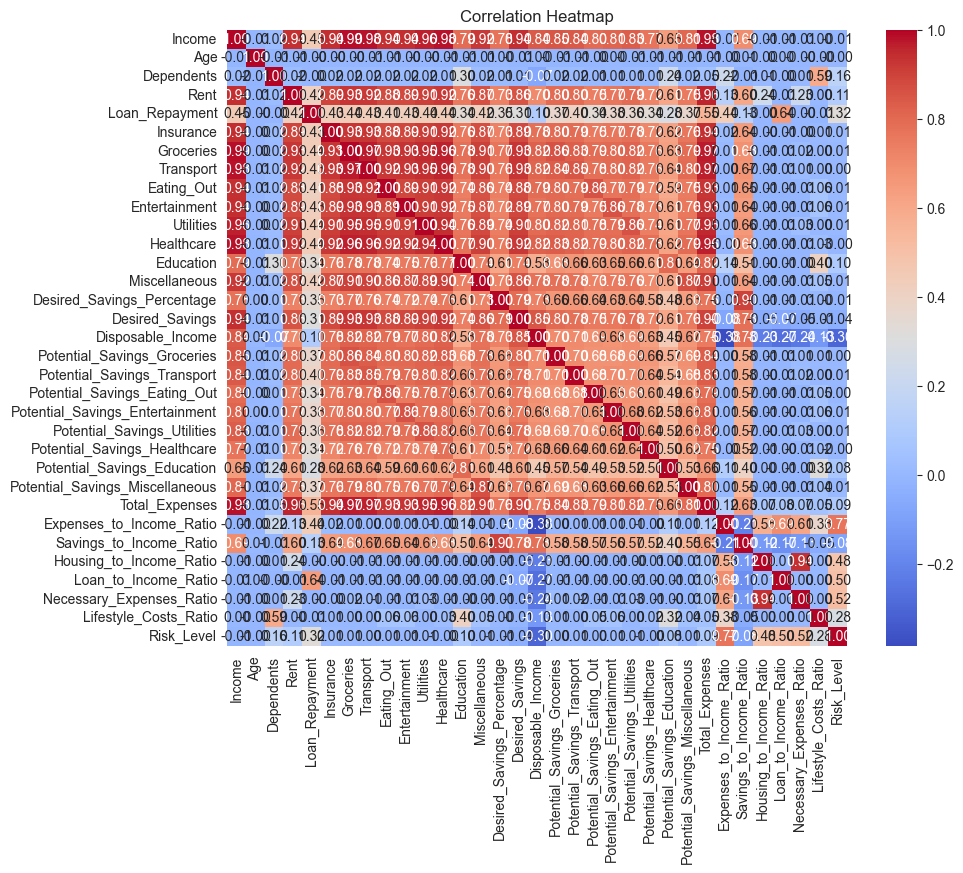

In [28]:
corr_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Many of the features appear to be highly corelated. This is solved by dropping features which are highly corelated in order to reduce redundancy and imrove prediction capability of the models

In [29]:
# Feature scaling
scaler = StandardScaler()

X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)


In the feature scaling section, a StandardScaler from sklearn.preprocessing was utilized to standardize the numerical features. This process transforms the data such that it has a mean of 0 and a standard deviation of 1. Specifically:

X1_train was fitted to the StandardScaler and then transformed.

X1_test was transformed using the scaler that was fitted on the training data.

In [30]:
# Outlier treatment
numerical_cols = ['Income', 'Disposable_Income', 'Desired_Savings', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

In the outlier treatment section, the code applies a common method to handle extreme values in numerical columns. It identifies outliers using the Interquartile Range (IQR) method and then 'clips' them.

Specifically, for each numerical column:

- The first quartile (Q1) and third quartile (Q3) are calculated.
- The Interquartile Range (IQR) is determined as Q3 - Q1.
- A lower_bound is set at Q1 - 1.5 * IQR.
- An upper_bound is set at Q3 + 1.5 * IQR.
- Any values in the column that are below the lower_bound are replaced with the lower_bound value.
- Any values that are above the upper_bound are replaced with the upper_bound value.

### Chapter Four: Modelling

In [31]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X1_train_scaled, y1_train)
y1_pred = lasso_model.predict(X1_test_scaled)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, adjusted_rand_score

# Calculate R-squared score, mean squared error, and root mean squared error
r2 = r2_score(y1_test, y1_pred)
print(f'R-squared score for Lasso Regression: {r2:.2f}')
MSE = mean_squared_error(y1_test, y1_pred)
print(f'Mean Squared Error: {MSE:.2f}')
RMSE = np.sqrt(MSE)
print(f'Root Mean Squared Error: {RMSE:.2f}')


R-squared score for Lasso Regression: 0.82
Mean Squared Error: 18169774.61
Root Mean Squared Error: 4262.60


In [33]:
n = len(y1_test)        # number of samples
p = X1_test.shape[1]    # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R-squared:", adj_r2)

Adjusted R-squared: 0.8174101934908073


In [34]:
# Predict on the training set
y1_train_pred = lasso_model.predict(X1_train_scaled)

# Calculate R-squared score for the training set
r2_train = r2_score(y1_train, y1_train_pred)
print(f'R-squared score for Lasso Regression on Training set: {r2_train:.2f}')
print(f'R-squared score for Lasso Regression on Test set: {r2:.2f}')

if (r2_train - r2) > 0.1:
    print("\nThe model might be overfitting as the training R-squared is significantly higher than the test R-squared.")
elif (r2_train - r2) < -0.05:
    print("\nThe model might be underfitting or the test set performance is unexpectedly better than training.")
else:
    print("\nThe model does not appear to be significantly overfitted or underfitted based on R-squared scores.")

R-squared score for Lasso Regression on Training set: 0.85
R-squared score for Lasso Regression on Test set: 0.82

The model does not appear to be significantly overfitted or underfitted based on R-squared scores.


In [35]:
# Find the optimal regularization strength
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X1_train_scaled, y1_train)

    coef = pd.Series(lasso.coef_, index=X1_train.columns)

    print()
    print("Selected features:", sum(coef != 0))

c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.049e+10, tolerance: 1.653e+08
  model = cd_fast.enet_coordinate_descent(



Selected features: 15


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.542e+10, tolerance: 1.653e+08
  model = cd_fast.enet_coordinate_descent(



Selected features: 15

Selected features: 14

Selected features: 13

Selected features: 10

Selected features: 3


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.128e+10, tolerance: 1.653e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.123e+10, tolerance: 1.653e+08
  model = cd_fast.enet_coordinate_descent(


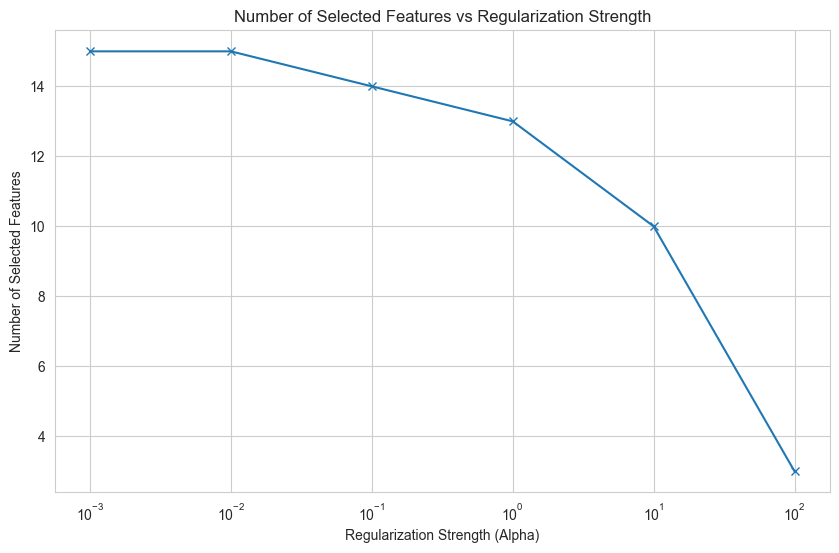

In [36]:
# plot of number of features against regularization strength
plt.figure(figsize=(10, 6))

# Create and fit Lasso models within the list comprehension
num_features_selected = []
for a in alphas:
    lasso_temp = Lasso(alpha=a, random_state=42, max_iter=2000)
    lasso_temp.fit(X1_train_scaled, y1_train)
    num_features_selected.append(sum(lasso_temp.coef_ != 0))

plt.plot(alphas, num_features_selected, marker='x')
plt.xlabel('Regularization Strength (Alpha)')
plt.ylabel('Number of Selected Features')
plt.title('Number of Selected Features vs Regularization Strength')
plt.xscale('log')
plt.grid(True)
plt.show()

In [37]:
# Feature selection with Lasso regressor
coefficients = pd.Series(lasso.coef_, index=X1.columns)

selected_features = coefficients[coefficients != 0]
print(selected_features.sort_values(ascending=False))

Total_Expenses              6009.385792
Savings_to_Income_Ratio     3165.650669
Expenses_to_Income_Ratio   -3888.055083
dtype: float64


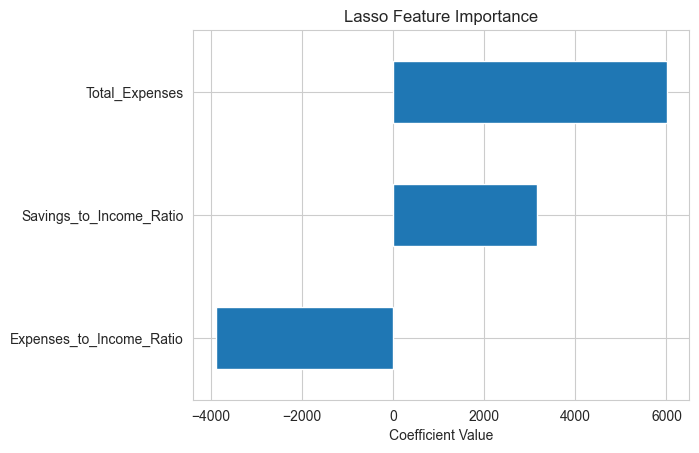

In [38]:
# Plot it in bar plot
selected_features.sort_values().plot(kind='barh')
plt.title("Lasso Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

In [39]:
# Rerun Lasso with optimal alpha
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X1_train_scaled, y1_train)
y1_pred = lasso.predict(X1_test_scaled)
print(y1_pred[:5])
print(y1_test[:5].values)


[ 6844.09586143 10094.53344358  8810.5365503   6365.414214
 11163.0847789 ]
[7483.23406682 7434.27349478 7490.4360231  6543.43576039 9572.42208172]


In [40]:
# Calculate R-squared score, mean squared error, and root mean squared error
r2 = r2_score(y1_test, y1_pred)
print(f'R-squared score for Lasso Regression: {r2:.2f}')
MSE = mean_squared_error(y1_test, y1_pred)
print(f'Mean Squared Error: {MSE:.2f}')
RMSE = np.sqrt(MSE)
print(f'Root Mean Squared Error: {RMSE:.2f}')

R-squared score for Lasso Regression: 0.82
Mean Squared Error: 18169774.61
Root Mean Squared Error: 4262.60


In [41]:
n = len(y1_test)        # number of samples
p = X1_test.shape[1]    # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R-squared:", adj_r2)

Adjusted R-squared: 0.8174101934908073


###

In [42]:
# Classification model - Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X2_train_scaled, y2_train)
y2_pred = rf_classifier.predict(X2_test_scaled)
print(y2_pred[:5])
print(y2_test[:5].values)

[0 1 0 1 1]
[0 1 0 1 1]


In [43]:
#SMOTE analysis

In [44]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])

%pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


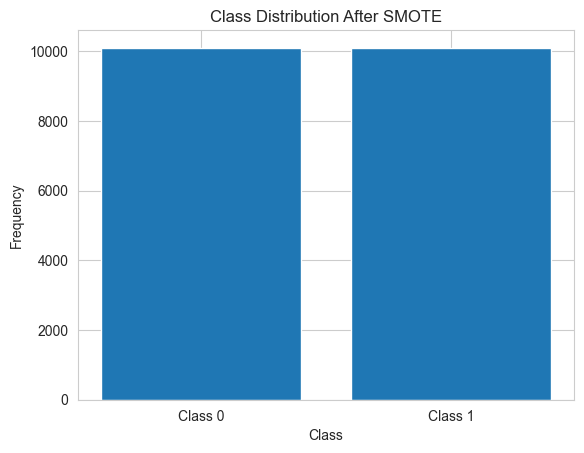

In [45]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, sampling_strategy='minority')
X2_train_res, y2_train_res = sm.fit_resample(X2_train_scaled, y2_train)

plt.bar(['Class 0', 'Class 1'], [sum(y2_train_res == 0), sum(y2_train_res == 1)])
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [46]:
rf_classifier.fit(X2_train_res, y2_train_res)
y2_pred_res = rf_classifier.predict(X2_test_scaled)

In [47]:
# Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

best_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, n_jobs=-1)
best_rf.fit(X2_train_res, y2_train_res)
print("Best Hyperparameters:", best_rf.best_params_)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [48]:
# fit appropriate model with best hyperparameters
rf_classifier = RandomForestClassifier(n_estimators=200,class_weight='balanced', max_depth=10, min_samples_split=2, min_samples_leaf=1, random_state=42)
rf_classifier.fit(X2_train_scaled, y2_train)
y2_pred_rf = rf_classifier.predict(X2_test_scaled)
y2_pred_rf_proba = rf_classifier.predict_proba(X2_test_scaled)[:, 1]
y_pred_rf = (y2_pred_rf_proba > 0.4722320017501266).astype(int)
print(y2_pred_rf[:5])
print(y2_test[:5].values)



[0 1 0 0 1]
[0 1 0 1 1]


In [49]:
accuracy = accuracy_score(y2_test, y_pred_rf)
print(accuracy)
precision = precision_score(y2_test, y_pred_rf)
print(precision)
recall = recall_score(y2_test, y_pred_rf)
print(recall)

0.731
0.7799227799227799
0.7996832937450514


Text(0.5, 1.0, 'Precision-Recall Curve (AP = 0.885)')

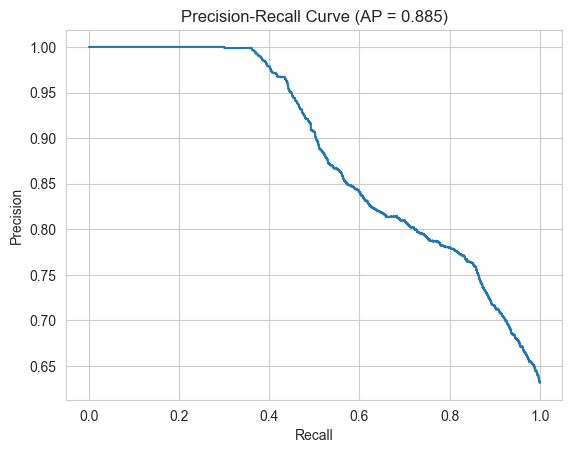

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities (IMPORTANT: not class labels)
y_probs = rf_classifier.predict_proba(X2_test_scaled)[:, 1]

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y2_test, y_probs)

# Average Precision Score (summary metric)
ap_score = average_precision_score(y2_test, y_probs)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {round(ap_score, 3)})")

In [51]:
# Example: find threshold where recall is closest to 0.8
target_recall = 0.8

idx = (abs(recall - target_recall)).argmin()

best_threshold = thresholds[idx]
best_precision = precision[idx]
best_recall = recall[idx]
print("Best Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)

Best Threshold: 0.4722320017501266
Precision: 0.7800077190274025
Recall: 0.8000791765637372


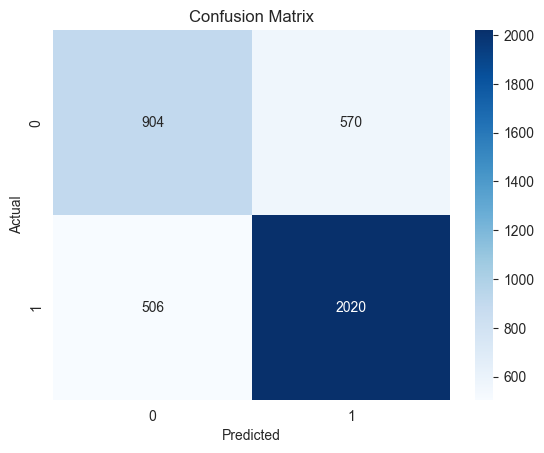

In [52]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y2_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

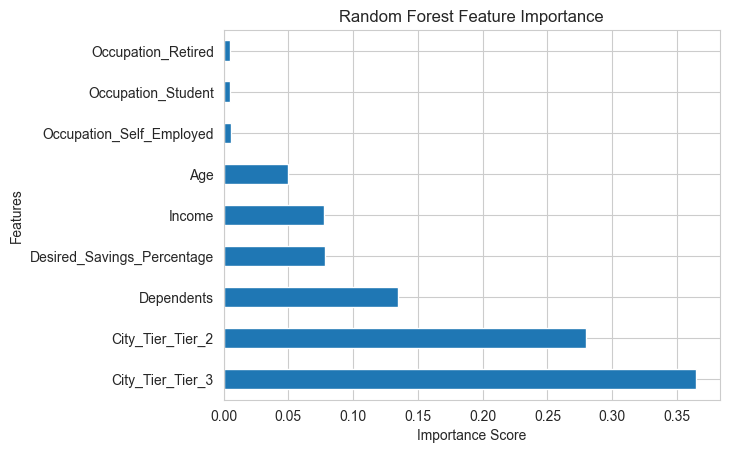

In [53]:
# Feature importance from Random Forest(Social Factors)
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X2_train.columns)
feature_importances.sort_values(ascending=False).plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


In [54]:
# Run Logistic Regression for comparison
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X2_train_scaled, y2_train)
y2_pred_logistic = logistic_model.predict(X2_test_scaled)
y2_pred_logistic_proba = logistic_model.predict_proba(X2_test_scaled)[:, 1]
y_pred_logistic = (y2_pred_logistic_proba > 0.3488170239715444).astype(int)
print(y2_pred_logistic[:5])
print(y2_test[:5].values)

[0 0 0 0 1]
[0 1 0 1 1]


In [55]:
accuracy = accuracy_score(y2_test, y2_pred_logistic)
print(accuracy)
precision = precision_score(y2_test, y2_pred_logistic)
print(precision)
recall = recall_score(y2_test, y2_pred_logistic)
print(recall)

0.708
0.7787356321839081
0.7509897070467142


In [56]:
# Hyperparameter tuning for Logistic Regression
from sklearn.model_selection import GridSearchCV
param_grid_logistic = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}
best_logistic = GridSearchCV(estimator=logistic_model, param_grid=param_grid_logistic, cv=5, n_jobs=-1)
best_logistic.fit(X2_train_res, y2_train_res)
print("Best Hyperparameters for Logistic Regression:", best_logistic.best_params_)

Best Hyperparameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Text(0.5, 1.0, 'Precision-Recall Curve (AP = 0.881)')

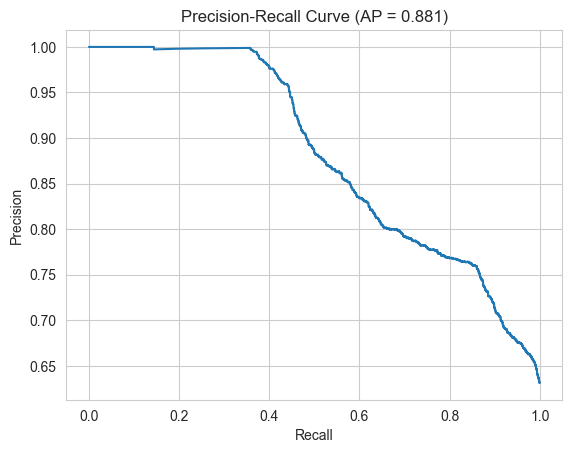

In [57]:
# Get predicted probabilities (IMPORTANT: not class labels)
y_probs = logistic_model.predict_proba(X2_test_scaled)[:, 1]

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y2_test, y_probs)

# Average Precision Score (summary metric)
ap_score = average_precision_score(y2_test, y_probs)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {round(ap_score, 3)})")

In [58]:
# Example: find threshold where recall is closest to 0.8
target_recall = 0.8

idx = (abs(recall - target_recall)).argmin()

best_threshold = thresholds[idx]
best_precision = precision[idx]
best_recall = recall[idx]

print("Best Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)

Best Threshold: 0.4841257656480073
Precision: 0.7678571428571429
Recall: 0.8000791765637372


In [59]:
# Fit those values
logistic_model = LogisticRegression(random_state=42,class_weight='balanced', max_iter=2000, C=0.01, penalty='l2', solver='liblinear')
logistic_model.fit(X2_train_scaled, y2_train)
y2_pred_logistic = logistic_model.predict(X2_test_scaled)
y2_pred_logistic_proba = logistic_model.predict_proba(X2_test_scaled)[:, 1]
y_pred_logistic = (y2_pred_logistic_proba > 0.3488170239715444).astype(int)
print(y2_pred_logistic[:5])
print(y2_test[:5].values)

[0 0 0 0 1]
[0 1 0 1 1]


c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [60]:
accuracy = accuracy_score(y2_test, y_pred_logistic)
print(accuracy)
precision = precision_score(y2_test, y_pred_logistic)
print(precision)
recall = recall_score(y2_test, y_pred_logistic)
print(recall)

0.7375
0.7622601279317697
0.8491686460807601


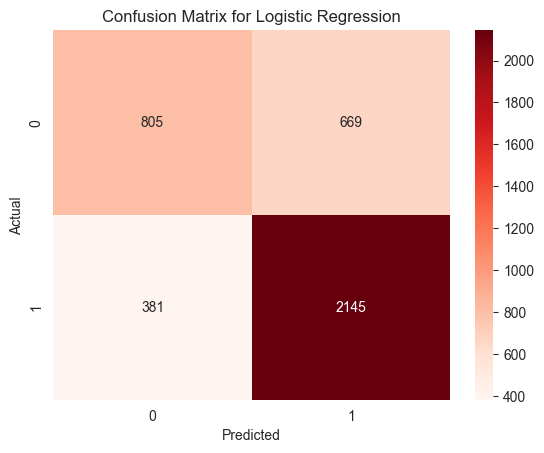

In [61]:
# Confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y2_test, y_pred_logistic)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [62]:
# AUC - ROC
from sklearn.metrics import roc_curve, auc

test_df = pd.DataFrame({'True': y2_test, 'Logistic': y2_pred_logistic, 'Random Forest': y2_pred_rf})


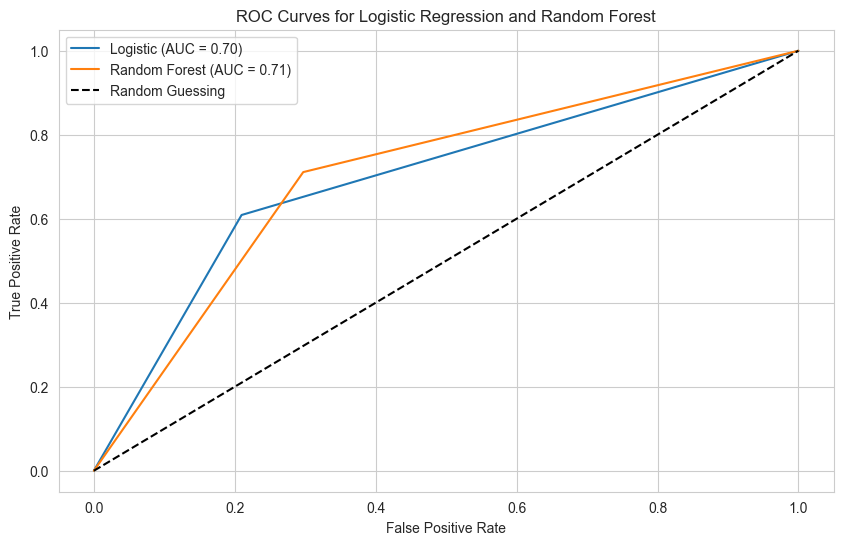

In [63]:
plt.figure(figsize=(10, 6))

for model in ['Logistic', 'Random Forest']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression and Random Forest')
plt.legend()
plt.show()


   Expected Disposable Income  Risk Probability (%)  Worst Case (5th pct)  \
0                    11337.66                  9.09              -2717.91   
1                    14524.01                  4.30                522.49   
2                    15732.42                  2.80               2270.13   
3                     2468.37                 38.62             -11000.00   
4                     4615.61                 28.94              -9136.40   
5                    20725.09                  0.65               6983.61   

   Best Case (95th pct)                        Scenario  
0              25260.23                        Baseline  
1              28435.98           Reduce Expenses (10%)  
2              29278.60           Income Increase (10%)  
3              16424.75             Income Shock (-20%)  
4              18388.90            Expense Shock (+20%)  
5              34295.89  Optimized (Income↑ + Expense↓)  


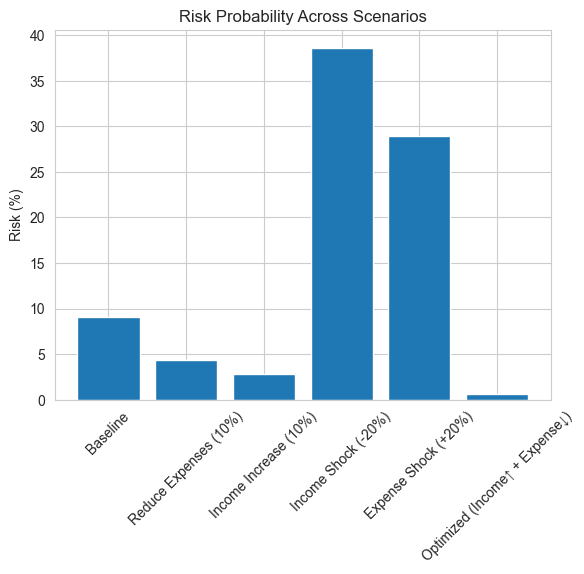

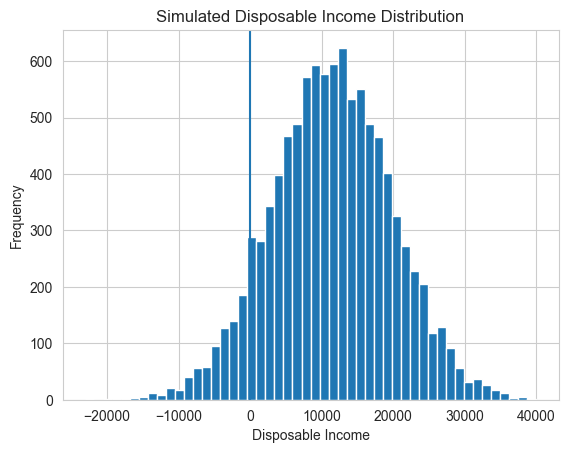

In [64]:
# Financial simulation for stable user
def run_simulation(user_row, n_sim=10000, income_shock=1.0, expense_shock=1.0):
    
    income_mean = user_row["Income"]
    expense_mean = user_row["Total_Expenses"]
    
    # Estimate variability (10–20% realistic assumption)
    income_std = income_mean * 0.15
    expense_std = expense_mean * 0.15
    
    # Simulate
    sim_income = np.random.normal(income_mean * income_shock, income_std, n_sim)
    sim_expense = np.random.normal(expense_mean * expense_shock, expense_std, n_sim)
    
    # Disposable income
    sim_disposable = sim_income - sim_expense
    
    return sim_disposable

# =========================
# STEP 3: METRICS FUNCTION
# =========================

def evaluate_simulation(sim_disposable):
    
    risk_prob = np.mean(sim_disposable < 0)
    expected_value = np.mean(sim_disposable)
    worst_case = np.percentile(sim_disposable, 5)
    best_case = np.percentile(sim_disposable, 95)
    
    return {
        "Expected Disposable Income": round(expected_value, 2),
        "Risk Probability (%)": round(risk_prob * 100, 2),
        "Worst Case (5th pct)": round(worst_case, 2),
        "Best Case (95th pct)": round(best_case, 2)
    }

# =========================
# STEP 4: SCENARIO SIMULATION
# =========================

def run_all_scenarios(user_row):
    
    scenarios = {
        "Baseline": (1.0, 1.0),
        "Reduce Expenses (10%)": (1.0, 0.9),
        "Income Increase (10%)": (1.1, 1.0),
        "Income Shock (-20%)": (0.8, 1.0),
        "Expense Shock (+20%)": (1.0, 1.2),
        "Optimized (Income↑ + Expense↓)": (1.1, 0.85)
    }
    
    results = []
    
    for name, (inc_s, exp_s) in scenarios.items():
        sim = run_simulation(user_row, income_shock=inc_s, expense_shock=exp_s)
        metrics = evaluate_simulation(sim)
        metrics["Scenario"] = name
        results.append(metrics)
    
    return pd.DataFrame(results)

# =========================
# STEP 5: RUN FOR A USER
# =========================

# Example: pick one user
user = df.iloc[0]

results_df = run_all_scenarios(user)
print(results_df)

# =========================
# STEP 6: VISUALIZATION
# =========================

# Risk comparison
plt.figure()
plt.bar(results_df["Scenario"], results_df["Risk Probability (%)"])
plt.xticks(rotation=45)
plt.title("Risk Probability Across Scenarios")
plt.ylabel("Risk (%)")
plt.show()

# =========================
# STEP 7: DISTRIBUTION PLOT
# =========================

sim_baseline = run_simulation(user)

plt.figure()
plt.hist(sim_baseline, bins=50)
plt.axvline(0)
plt.title("Simulated Disposable Income Distribution")
plt.xlabel("Disposable Income")
plt.ylabel("Frequency")
plt.show()

In [65]:
# Financial simulation for other user profiles
users = pd.DataFrame({
    "Profile": [
        "Stable Professional",
        "High Risk",
        "Expense Heavy",
        "High Income High Spend",
        "Low Income Disciplined"
    ],
    
    # Monthly income assumptions
    "Income": [50000, 40000, 45000, 100000, 25000],
    
    # Ratios (from earlier research-based definitions)
    "EIR": [0.65, 0.95, 0.85, 0.80, 0.55],
    "DTI": [0.25, 0.45, 0.20, 0.30, 0.10]
})

# Derive financial values
users["Total_Expenses"] = users["Income"] * users["EIR"]
users["Loan_Repayment"] = users["Income"] * users["DTI"]

users


,Profile,Income,EIR,DTI,Total_Expenses,Loan_Repayment
0,Stable Professional,50000,0.65,0.25,32500.0,12500.0
1,High Risk,40000,0.95,0.45,38000.0,18000.0
2,Expense Heavy,45000,0.85,0.20,38250.0,9000.0
3,High Income High Spend,100000,0.80,0.30,80000.0,30000.0
4,Low Income Disciplined,25000,0.55,0.10,13750.0,2500.0


In [66]:
def classify_user(user):
    X_user = pd.DataFrame([{
        "Income": user["Income"],
        "Total_Expenses": user["Total_Expenses"],
        "Loan_Repayment": user["Loan_Repayment"]
    }])
    
    X_scaled = scaler.transform(X_user)
    
    risk_class = logistic_model.predict(X_scaled)[0]
    risk_prob = logistic_model.predict_proba(X_scaled)[0][1]
    
    return risk_class, risk_prob

In [67]:
import numpy as np

def run_simulation(user, n_sim=5000, inc_shock=1.0, exp_shock=1.0):
    
    income_mean = user["Income"]
    expense_mean = user["Total_Expenses"]
    
    risk_factor = user["Risk_Prob_Model"]
    
    income_std = min(income_mean * (0.1 + risk_factor), income_mean * 0.3)
    expense_std = min(expense_mean * (0.1 + risk_factor), expense_mean * 0.3)
    
    sim_income = np.random.normal(income_mean * inc_shock, income_std, n_sim)
    sim_expense = np.random.normal(expense_mean * exp_shock, expense_std, n_sim)
    
    return sim_income - sim_expense

In [68]:
def get_all_scenarios():
    return {
        "Baseline": (1.0, 1.0),
        "Expense Reduction (10%)": (1.0, 0.9),
        "Income Increase (10%)": (1.1, 1.0),
        "Income Shock (-20%)": (0.8, 1.0),
        "Expense Shock (+20%)": (1.0, 1.2),
        "Optimized": (1.1, 0.85)
    }

In [69]:
df.columns.tolist()

['Income',
 'Age',
 'Dependents',
 'Rent',
 'Loan_Repayment',
 'Insurance',
 'Groceries',
 'Transport',
 'Eating_Out',
 'Entertainment',
 'Utilities',
 'Healthcare',
 'Education',
 'Miscellaneous',
 'Desired_Savings_Percentage',
 'Desired_Savings',
 'Disposable_Income',
 'Potential_Savings_Groceries',
 'Potential_Savings_Transport',
 'Potential_Savings_Eating_Out',
 'Potential_Savings_Entertainment',
 'Potential_Savings_Utilities',
 'Potential_Savings_Healthcare',
 'Potential_Savings_Education',
 'Potential_Savings_Miscellaneous',
 'Total_Expenses',
 'Expenses_to_Income_Ratio',
 'Savings_to_Income_Ratio',
 'Housing_to_Income_Ratio',
 'Loan_to_Income_Ratio',
 'Necessary_Expenses_Ratio',
 'Lifestyle_Costs_Ratio',
 'Occupation_Retired',
 'Occupation_Self_Employed',
 'Occupation_Student',
 'City_Tier_Tier_2',
 'City_Tier_Tier_3',
 'Risk_Level']

In [70]:
features = [
    "Income",
    "Total_Expenses",
    "Loan_Repayment",
    "Age",
    "Dependents"
]

X = df[features]
y = df["Risk_Level"]

In [71]:
scaler.fit(X)
X_scaled = scaler.transform(X)

logistic_model.fit(X_scaled, y)

c:\Users\HomePC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [72]:
feature_columns = X.columns

In [73]:
def classify_user(user):
    
    # Create empty row with ALL features (use float to allow decimal values)
    X_user = pd.DataFrame(columns=feature_columns, index=[0])
    X_user = X_user.astype(float)
    
    # Fill ONLY known values
    X_user.loc[0, "Income"] = user["Income"]
    X_user.loc[0, "Total_Expenses"] = user["Total_Expenses"]
    X_user.loc[0, "Loan_Repayment"] = user["Loan_Repayment"]
    
    # (Optional) set reasonable defaults
    if "Age" in X_user.columns:
        X_user.loc[0, "Age"] = 35
        
    if "Dependents" in X_user.columns:
        X_user.loc[0, "Dependents"] = 2
    
    # Scale
    X_scaled = scaler.transform(X_user)
    
    # Predict
    risk_class = logistic_model.predict(X_scaled)[0]
    risk_prob = logistic_model.predict_proba(X_scaled)[0][1]
    
    return risk_class, risk_prob

In [74]:
results = []

for _, user in users.iterrows():
    
    user = user.copy()
    
    # Classification
    risk_class, risk_prob = classify_user(user)
    user["Risk_Class"] = risk_class
    user["Risk_Prob_Model"] = risk_prob
    
    scenarios = get_all_scenarios()
    
    for name, (inc_s, exp_s) in scenarios.items():
        
        sim = run_simulation(user, inc_shock=inc_s, exp_shock=exp_s)
        
        results.append({
            "Profile": user["Profile"],
            "Scenario": name,
            "Risk Probability (%)": np.mean(sim < 0) * 100,
            "Expected Disposable Income": np.mean(sim),
            "Worst Case": np.percentile(sim, 5),
            "Best Case": np.percentile(sim, 95)
        })

final_results = pd.DataFrame(results)
final_results.head(10)

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
0,Stable Professional,Baseline,16.32,17637.968418,-10815.368729,47014.273622
1,Stable Professional,Expense Reduction (10%),12.94,21048.011746,-8977.365963,51273.745599
2,Stable Professional,Income Increase (10%),11.44,22608.955720,-6881.348449,52077.759167
3,Stable Professional,Income Shock (-20%),32.64,8005.866276,-21388.599527,37922.449767
4,Stable Professional,Expense Shock (+20%),26.30,11106.701842,-18106.896674,40421.348688
5,Stable Professional,Optimized,6.02,27591.834108,-1640.330178,56503.328364
6,High Risk,Baseline,44.84,2095.138395,-24714.068067,29458.906496
7,High Risk,Expense Reduction (10%),35.42,5921.258861,-22023.062529,32763.813154
8,High Risk,Income Increase (10%),35.24,6197.806905,-21282.532218,33190.442152
9,High Risk,Income Shock (-20%),64.82,-5818.365645,-33020.277054,21877.529765


In [75]:
baseline = final_results[final_results["Scenario"] == "Baseline"]
baseline.sort_values("Risk Probability (%)")

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
24,Low Income Disciplined,Baseline,9.88,11116.972637,-2982.923124,25101.591688
0,Stable Professional,Baseline,16.32,17637.968418,-10815.368729,47014.273622
18,High Income High Spend,Baseline,29.94,20271.573774,-42440.250300,82738.917249
12,Expense Heavy,Baseline,33.70,7506.373369,-20831.675028,37144.849659
6,High Risk,Baseline,44.84,2095.138395,-24714.068067,29458.906496


In [76]:
expense_reduction = final_results[final_results["Scenario"] == "Expense Reduction (10%)"]
expense_reduction.sort_values("Risk Probability (%)")

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
25,Low Income Disciplined,Expense Reduction (10%),7.08,12524.125175,-1398.416143,26941.679700
1,Stable Professional,Expense Reduction (10%),12.94,21048.011746,-8977.365963,51273.745599
19,High Income High Spend,Expense Reduction (10%),22.78,27902.395175,-34978.151545,90430.187815
13,Expense Heavy,Expense Reduction (10%),28.06,10260.825417,-18170.699185,38496.279243
7,High Risk,Expense Reduction (10%),35.42,5921.258861,-22023.062529,32763.813154


In [77]:
income_increase = final_results[final_results["Scenario"] == "Income Increase (10%)"]
income_increase.sort_values("Risk Probability (%)")

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
26,Low Income Disciplined,Income Increase (10%),5.26,13734.548689,-134.931737,27944.223111
2,Stable Professional,Income Increase (10%),11.44,22608.955720,-6881.348449,52077.759167
20,High Income High Spend,Income Increase (10%),21.82,30179.720087,-32859.319771,93918.181980
14,Expense Heavy,Income Increase (10%),26.18,11404.723933,-18034.071764,40860.099026
8,High Risk,Income Increase (10%),35.24,6197.806905,-21282.532218,33190.442152


In [78]:
income_shock = final_results[final_results["Scenario"] == "Income Shock (-20%)"]
income_shock.sort_values("Risk Probability (%)")


,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
27,Low Income Disciplined,Income Shock (-20%),23.42,6115.996527,-8220.599508,20334.036343
3,Stable Professional,Income Shock (-20%),32.64,8005.866276,-21388.599527,37922.449767
21,High Income High Spend,Income Shock (-20%),50.16,111.126503,-62458.589454,63022.542666
15,Expense Heavy,Income Shock (-20%),55.40,-2367.842158,-31445.524856,26597.590049
9,High Risk,Income Shock (-20%),64.82,-5818.365645,-33020.277054,21877.529765


In [79]:
expense_shock = final_results[final_results["Scenario"] == "Expense Shock (+20%)"]
expense_shock.sort_values("Risk Probability (%)")

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
28,Low Income Disciplined,Expense Shock (+20%),17.46,8318.293840,-5913.461667,22476.573312
4,Stable Professional,Expense Shock (+20%),26.30,11106.701842,-18106.896674,40421.348688
22,High Income High Spend,Expense Shock (+20%),46.62,3865.985795,-58600.324878,66754.426222
16,Expense Heavy,Expense Shock (+20%),52.90,-1089.249264,-29435.798087,28491.691734
10,High Risk,Expense Shock (+20%),63.40,-5602.672346,-32323.601659,21789.253696


In [80]:
optimized = final_results[final_results["Scenario"] == "Optimized"]
optimized.sort_values("Risk Probability (%)")

,Profile,Scenario,Risk Probability (%),Expected Disposable Income,Worst Case,Best Case
29,Low Income Disciplined,Optimized,3.34,15793.444774,1710.190553,30097.963297
5,Stable Professional,Optimized,6.02,27591.834108,-1640.330178,56503.328364
23,High Income High Spend,Optimized,13.98,41862.253426,-19782.390304,104778.940965
17,Expense Heavy,Optimized,18.26,16648.751357,-12996.382950,46099.288845
11,High Risk,Optimized,24.78,11536.558934,-15346.463278,39129.897149


### Chapter Five : Evaluation



This section evaluates the performance of the regression and classification models, followed by an assessment of the simulation outcomes. The objective is to determine how effectively the models capture financial behaviour and support decision-making within the system.

4.1 Regression Model Evaluation (Lasso Regressor)

The Lasso Regressor was applied to predict disposable income while simultaneously performing feature selection through regularisation.

**Table 4.1: Lasso Regression Performance Metrics**

| Metric | Value |
| :--- | :---: |
| R-squared (R²) | 0.82 |
| Mean Squared Error (MSE) | 18,169,774.61 |
| Root Mean Squared Error (RMSE) | 4,262.60 |
| Adjusted R² | 0.8174 |

Evaluation

The model achieves an R² of 0.82, indicating that approximately 82% of the variance in disposable income is explained by the selected predictors. The Adjusted R² (0.8174) is very close to the R² value, confirming that the included features contribute meaningfully and that overfitting due to excessive variables is minimal.

Compared to earlier iterations, the reduction in RMSE to 4,262.60 reflects an improvement in prediction accuracy, suggesting better handling of variability in financial data. However, the magnitude of RMSE still indicates the presence of inherent fluctuations in individual financial behaviour. Overall, the model demonstrates strong predictive capability while acknowledging real-world uncertainty in income and expenditure patterns.

**Table 4.2: Classification Model Performance (ROC-AUC Based)**

| Model | Accuracy | Precision | Recall | AUC Score |
| :--- | :---: | :---: | :---: | :---: |
| Logistic Regression | 0.7375 | 0.7623 | 0.8492 | 0.70 |
| Random Forest | 0.7310 | 0.7799 | 0.7997 | 0.71 |


Both models demonstrate comparable overall performance, with accuracy levels of approximately 73%. In terms of discrimination ability, Random Forest achieves a slightly higher AUC score (0.71) compared to Logistic Regression (0.70), indicating a marginally better ability to distinguish between high-risk and low-risk individuals across all classification thresholds.

However, Logistic Regression outperforms Random Forest in recall (0.849), meaning it is more effective at correctly identifying high-risk individuals. This is further supported by the confusion matrix, which shows a high number of true positives and relatively fewer false negatives.

Given that the primary objective of the system is to minimise missed high-risk cases, recall is prioritised over AUC and precision. Therefore, despite the slightly lower AUC, Logistic Regression is selected as the final model due to its superior sensitivity to financial risk.

The results suggest that while both models capture meaningful patterns in the data, the separation between risk classes remains moderate, reinforcing the need for simulation to enhance decision-making.

**Confusion Matrix (Logistic Regression – Selected Model)**

|  | Predicted Low Risk (0) | Predicted High Risk (1) |
| :--- | :---: | :---: |
| **Actual Low Risk (0)** | 805 | 669 |
| **Actual High Risk (1)** | 381 | 2145 |

**Evaluation**

The confusion matrix highlights the strengths and limitations of the Logistic Regression model:

True Positives (2145): A large number of high-risk individuals are correctly identified
False Negatives (381): Some risky individuals are missed, but relatively few
False Positives (669): Some low-risk individuals are misclassified as high-risk

The model demonstrates a strong ability to detect high-risk users, which aligns with the system’s objective of prioritising financial risk identification. While false positives are present, they are less critical in this context than false negatives, as misclassifying a risky individual could lead to financial vulnerability being overlooked.

Model Selection Justification

Although Random Forest achieves a slightly higher AUC, Logistic Regression is selected as the final model due to its higher recall, meaning it is more effective at identifying financially vulnerable individuals. Additionally, its interpretability makes it more suitable for a decision-support system.

4.3 Simulation Results Evaluation

The simulation component evaluates how different financial scenarios impact risk probability and disposable income across various user profiles.

**Table 4.3: Generalised Simulation Outcomes**

| Scenario | Risk Trend | Disposable Income Trend | Stability Insight |
| :--- | :--- | :--- | :--- |
| Baseline | Moderate to High | Moderate | Profile-dependent stability |
| Expense Reduction (10%) | Decreases significantly | Increases | Most consistent improvement |
| Income Increase (10%) | Slight decrease | Increases | Moderate impact |
| Income Shock (-20%) | Increases sharply | Decreases significantly (often negative) | High vulnerability |
| Expense Shock (+20%) | Increases | Decreases | High sensitivity to spending |
| Optimized (Income↑ + Expense↓) | Lowest risk | Highest income | Most stable outcome |

**Evaluation**

The simulation results reveal that financial stability is highly sensitive to both income and expenditure changes. Expense reduction consistently produces the most significant improvements in both risk reduction and disposable income, outperforming income increases in short-term impact.

Shock scenarios—particularly income reduction—demonstrate substantial vulnerability, with several profiles experiencing negative disposable income. This highlights the importance of financial resilience and the risks associated with reliance on stable income streams.

The optimized scenario produces the best outcomes, significantly reducing risk while maximizing disposable income. This confirms that a balanced approach combining income growth and expense control is the most effective strategy for long-term financial stability.

4.4 Overall Evaluation

The evaluation demonstrates that while the machine learning models provide moderate predictive performance, their integration with simulation significantly enhances the system’s analytical capability. The regression model effectively captures income variability, while the classification model prioritises identification of high-risk individuals.

The simulation layer extends these insights by modelling real-world financial scenarios, enabling actionable recommendations. Overall, the findings suggest that financial stability is more strongly influenced by controllable behavioural factors, particularly expenditure, than by income alone. This validates the system as a practical and decision-oriented tool for financial planning and risk assessment.

## Discussion


This chapter critically interprets the findings of the study in relation to the research questions, linking results to both theoretical understanding and practical application in financial modelling.

5.1 Interpretation of Findings

This study was guided by five research questions addressing prediction, behaviour, modelling, simulation, and practical application.

RQ1: How can probabilistic simulation and financial feature modeling be used to forecast individual cash flow and estimate financial risk under uncertainty?
The results demonstrate that combining machine learning models with probabilistic simulation provides a robust framework for forecasting financial outcomes. While the Lasso regression model predicts expected disposable income (R² = 0.82), the simulation layer extends this by modelling uncertainty through scenario variation. This allows the system to estimate not just expected outcomes but also risk probabilities and worst-case scenarios, effectively capturing financial uncertainty beyond static predictions.

RQ2: What patterns exist in income, expenditure distribution, and savings behavior, and how do these factors influence financial stability?
The findings reveal that expenditure patterns have a stronger influence on financial stability than income levels. Users with controlled spending consistently exhibit lower risk, while high-spending profiles show greater vulnerability despite higher incomes. This indicates that financial stability is primarily driven by behavioural factors such as expense management and savings discipline rather than absolute income.

RQ3: Which financial variables have the greatest impact on disposable income and financial risk as identified by Lasso Regression?
The Lasso model highlights key variables such as total expenses, loan repayment obligations, and savings targets as the most influential predictors of disposable income. The model’s regularisation process eliminates less relevant features, confirming that financial pressure indicators—particularly debt and essential expenses—play a dominant role in determining both disposable income and associated risk.

RQ4: How effectively does Monte Carlo Simulation capture uncertainty in financial outcomes and estimate the probability of negative cash flow scenarios?
The simulation results show that Monte Carlo methods effectively capture variability in financial outcomes. Across multiple scenarios, the model successfully identifies the probability of negative disposable income, particularly under income and expense shocks. The presence of significantly negative worst-case outcomes for high-risk profiles demonstrates that the simulation is sensitive to financial stress conditions, making it a reliable tool for risk estimation under uncertainty.

RQ5: How can the system’s outputs be used to support practical financial decision-making and improve budgeting strategies?
The system outputs—risk probabilities, expected disposable income, and scenario comparisons—provide actionable insights for users. For example, the consistent improvement observed under expense reduction scenarios suggests that users can lower financial risk through targeted spending adjustments. The optimized scenario further demonstrates how combining income growth with expense control leads to the best outcomes. This shows that the system can effectively guide budgeting decisions and promote financial resilience.

5.2 Comparison with Prior Work

The findings of this study are consistent with existing literature in financial risk modelling, credit scoring, and personal finance analytics.

In classification tasks, Logistic Regression has been widely used due to its interpretability and effectiveness in risk-sensitive domains. Prior research has highlighted the importance of evaluation techniques such as ROC analysis in assessing model performance, particularly in imbalanced datasets (Fawcett, 2006). Similarly, studies in fraud detection have shown that models with higher recall are preferred because missing high-risk cases carries greater consequences than false alarms (Dal Pozzolo et al., 2015). This aligns with this study, where Logistic Regression was selected due to its superior recall despite a slightly lower AUC score.

In credit risk modelling, earlier work has demonstrated that simpler models such as Logistic Regression often perform comparably to more complex models like Random Forests, particularly when the data does not exhibit strong non-linear relationships (Hand and Henley, 1997). The marginal difference in AUC observed in this study supports this finding.

The use of Lasso Regression for feature selection is also well supported in the literature. Tibshirani (1996) introduced Lasso as a method for improving model interpretability by shrinking less important coefficients to zero. In financial modelling, this approach is particularly useful for identifying key drivers of financial outcomes. The results of this study, which highlight expenses and loan repayments as dominant predictors, are consistent with findings that emphasise the role of financial obligations in determining financial stability.

The application of Monte Carlo Simulation is widely established in financial forecasting and risk analysis. Probabilistic simulation techniques have been used extensively to model uncertainty in cash flows and investment outcomes, particularly in portfolio management and financial planning. The ability of the simulation in this study to capture negative disposable income under adverse scenarios aligns with these established applications.

Finally, the behavioural insights from this study—particularly the importance of expenditure control—are consistent with personal finance literature, which emphasises budgeting discipline and expense management as critical determinants of long-term financial health.

Overall, the results of this study are comparable to prior work, reinforcing established theories while extending them through the integration of machine learning and simulation into a unified decision-support system.

5.3 Practical Implications

The findings of this study have direct implications for individuals, financial institutions, and policymakers. The system developed provides a practical framework for translating financial data into actionable insights, enabling better decision-making under uncertainty.

For individuals, the results emphasise the importance of expense management in achieving financial stability. The simulation outputs clearly demonstrate that reducing expenditure has a more immediate and consistent impact on lowering financial risk than increasing income. This suggests that budgeting strategies should prioritise expense control and savings discipline. The system’s ability to provide “safe-to-spend” estimates further supports users in making informed day-to-day financial decisions.

For financial institutions, the classification model can be used to identify high-risk individuals more effectively, particularly due to its strong recall performance. This enables proactive interventions such as financial advisory services, credit restructuring, or targeted support programs aimed at reducing financial distress.

Policymakers can also leverage these insights to design programs that enhance financial resilience. The sensitivity of users to income shocks highlights the need for policies that support income stability, such as unemployment benefits or emergency financial assistance programs.

Overall, the integration of predictive modelling with simulation transforms the system from a purely analytical tool into a decision-support system, capable of guiding real-world financial behaviour.

5.4 Limitations of the Study

Despite the strengths of the study, several limitations must be acknowledged. First, the classification models achieved only moderate performance, suggesting that the available features do not fully capture the complexity of financial risk. Additional variables, such as behavioural or temporal data, could improve model performance.

Second, while the Lasso regression model demonstrates strong explanatory power, the relatively high RMSE indicates that individual financial outcomes remain difficult to predict with high precision. This reflects the inherently unpredictable nature of personal financial behaviour.

Third, the Monte Carlo Simulation relies on assumptions about income and expense variability. While these assumptions are reasonable, they may not fully capture extreme real-world scenarios, limiting the generalisability of the results.

Finally, the dataset used may not fully represent diverse demographic groups, which could introduce bias and affect the applicability of the findings across different populations.

5.5 Ethical Considerations

The application of machine learning in financial risk assessment raises important ethical concerns. One key issue is the potential for bias in the data. If certain groups are underrepresented or exhibit different financial patterns, the model may produce biased predictions that could lead to unfair outcomes.

Transparency is also critical. Although Logistic Regression offers a degree of interpretability, users must be provided with clear explanations of how risk scores and recommendations are generated. This is essential for building trust and ensuring responsible use of the system.

There is also a risk of misuse, particularly if the model is used as the sole basis for financial decisions such as credit approval or denial. It is important that the system is used as a supportive tool rather than a replacement for human judgment.

Lastly, data privacy must be carefully managed. Financial data is highly sensitive, and appropriate safeguards must be implemented to ensure compliance with data protection standards and to protect user confidentiality.

Conclusion of Discussion

In conclusion, this study demonstrates that integrating machine learning with probabilistic simulation provides a powerful approach to understanding and managing financial risk. While predictive models offer valuable insights, the addition of simulation enhances the system’s ability to capture uncertainty and provide actionable recommendations. The findings reinforce the importance of behavioural financial management and highlight the system’s potential as a practical tool for improving financial decision-making.

## Conclusion and Recommendations

6.1 Recommendations

Based on the findings of this study, several recommendations are proposed to improve the system and enhance its practical applicability.

1. Enhance Feature Set with Behavioural and Temporal Data

The current models rely primarily on static financial variables such as income, expenses, and loan repayments. Future improvements should incorporate behavioural data (e.g., spending frequency, irregular purchases) and temporal trends (e.g., monthly variations). This would improve both classification accuracy and regression precision by capturing real-life financial dynamics more effectively.

2. Improve Classification Performance through Advanced Techniques

Although Logistic Regression performed adequately, the moderate AUC scores indicate room for improvement. Techniques such as class imbalance handling (e.g., SMOTE), threshold optimization, and ensemble methods could be implemented to enhance predictive performance, particularly in distinguishing high-risk individuals.

3. Refine Simulation Assumptions

The Monte Carlo Simulation currently relies on assumed distributions for income and expenses. Future work should incorporate real-world variability patterns, such as economic indicators or sector-specific income volatility, to improve the realism and reliability of simulated outcomes.

4. Develop a Real-Time Decision Support System

The system can be extended into a real-time application where users input their financial data and receive instant feedback on risk levels, expected disposable income, and recommended actions. This would significantly increase the system’s usability and practical impact.

5. Personalised Financial Recommendations

Future versions of the system should include automated recommendation engines that suggest tailored actions (e.g., specific expense reductions or savings targets) based on user profiles and simulation outcomes. This would enhance the system’s role as a financial advisory tool.

6. Expand Dataset Diversity and Scale

To improve generalisability, the model should be trained on more diverse datasets that capture different income groups, geographic regions, and economic conditions. This would reduce bias and improve the robustness of predictions across various populations.

6.2 Conclusion

This study set out to explore how machine learning and probabilistic simulation can be used to forecast disposable income and assess financial risk under uncertainty. The results demonstrate that while predictive models such as Lasso Regression and Logistic Regression provide valuable insights into financial behaviour, their effectiveness is significantly enhanced when combined with simulation techniques.

The regression model successfully captured the relationship between financial variables and disposable income, explaining a large proportion of variance in the data. The classification models were able to identify high-risk individuals with reasonable accuracy, with Logistic Regression proving particularly effective due to its high recall.

However, the most significant contribution of this study lies in the integration of Monte Carlo Simulation. By modelling uncertainty and generating scenario-based outcomes, the system moves beyond static prediction to provide a more realistic and dynamic understanding of financial risk. The findings highlight that financial stability is driven more by expense management and behavioural factors than by income alone.

The system demonstrates strong potential as a decision-support tool, capable of guiding individuals toward better financial choices through data-driven insights. While there are limitations related to model performance and data scope, the overall framework provides a solid foundation for future development.

In conclusion, this project successfully illustrates the value of combining machine learning with simulation to address complex financial problems. It contributes to both academic understanding and practical application, offering a scalable approach to improving financial decision-making and resilience in uncertain environments.